In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.optimize import linprog, linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
warnings.simplefilter("ignore")

In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)
print(matplotlib.__version__)

3.6.3


In [3]:
DEBUG = True

In [4]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content_reduced": "Reduced Attrs Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

In [5]:
colors = dict()
colors['content_reduced'] = 'tab:green'
colors['pop'] = 'tab:red'
colors['sf'] = 'tab:brown'
colors['mf'] = 'tab:purple'
colors['ideal'] = 'tab:blue'
colors['random'] = 'tab:pink'

In [6]:
folder_paths = ["testing_feeds\\dynamic\\all_random_ideal_0"]

In [7]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()

In [8]:
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [9]:
interactions = dict()
for mo in id_to_readable.keys():
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [10]:
utilities = dict()
for mo in id_to_readable.keys():
    utilities[mo] = np.array(final_results['utility_history'][mo])
    utilities[mo] = np.transpose(utilities[mo], axes=[0,2,1])

In [11]:
traits = dict()
for mo in id_to_readable.keys():
    traits[mo] = np.array(final_results['trait_history'][mo])
    traits[mo] = np.transpose(traits[mo], axes=[0,2,1,3])

# Métricas

## Diversidad

### Inter-User Diversity

In [239]:
inter_user_div = dict()
for mo in interactions.keys():
    inter_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_mean = mean_user_attrs.mean(axis=0)
            distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
            variance = ((distances**2).sum())/distances.shape[0]
            re.append(variance**0.5)
        inter_user_div[mo].append(re)
    inter_user_div[mo] = np.array(inter_user_div[mo])

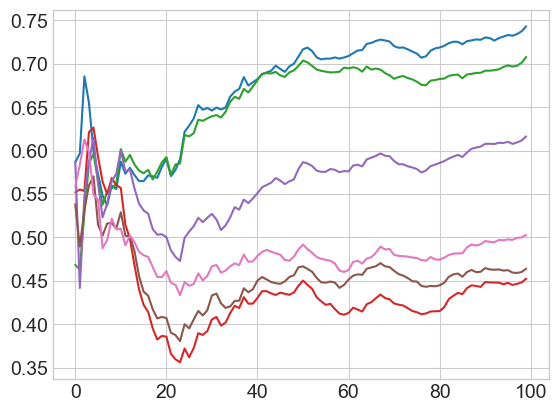

In [240]:
_mo_list = np.array([inter_user_div[mo] for mo in interactions.keys()])
inter_user_div_min = _mo_list.reshape((-1, _mo_list.shape[2])).min(axis=0)
inter_user_div_max = _mo_list.reshape((-1, _mo_list.shape[2])).max(axis=0)
norm_inter_user_div = dict()
for mo in interactions.keys():
    norm_inter_user_div[mo] = ((inter_user_div[mo] - inter_user_div_min)/(inter_user_div_max-inter_user_div_min))
    values = gaussian_filter1d(norm_inter_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[0:], color=colors[mo])
plt.show()

### Intra-User Diversity

In [241]:
intra_user_div = dict()
for mo in interactions.keys():
    intra_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
            distances = np.linalg.norm(diff_vectors, axis=2)
            variances = ((distances**2).sum(axis=1))/(distances.shape[1])
            re.append((variances**0.5).mean())
        intra_user_div[mo].append(re)
    intra_user_div[mo] = np.array(intra_user_div[mo])

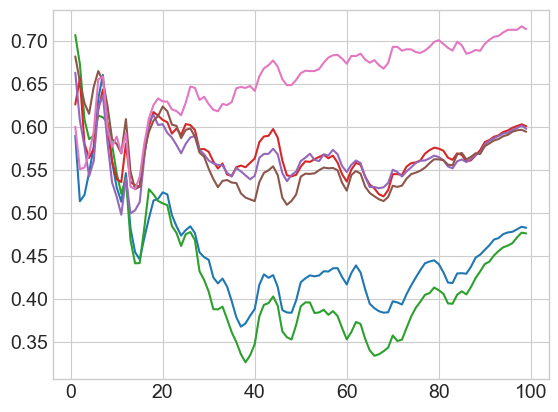

In [242]:
_mo_list = np.array([intra_user_div[mo] for mo in interactions.keys()])
intra_user_div_min = _mo_list.reshape((-1, _mo_list.shape[2])).min(axis=0)
intra_user_div_max = _mo_list.reshape((-1, _mo_list.shape[2])).max(axis=0)
norm_intra_user_div = dict()
for mo in interactions.keys():
    norm_intra_user_div[mo] = ((intra_user_div[mo] - intra_user_div_min)/(intra_user_div_max-intra_user_div_min))
    values = gaussian_filter1d(norm_intra_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[0:], color=colors[mo])
plt.show()

### Filter Bubble Effect

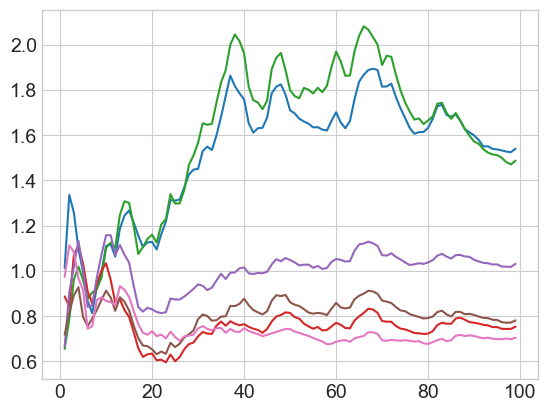

In [243]:
for mo in interactions.keys():
    fbe = (norm_inter_user_div[mo].mean(axis=0)/norm_intra_user_div[mo].mean(axis=0))
    values = gaussian_filter1d(fbe, sigma=0.1)
    plt.plot(values[0:], color=colors[mo])
plt.show()

### General Homogenization

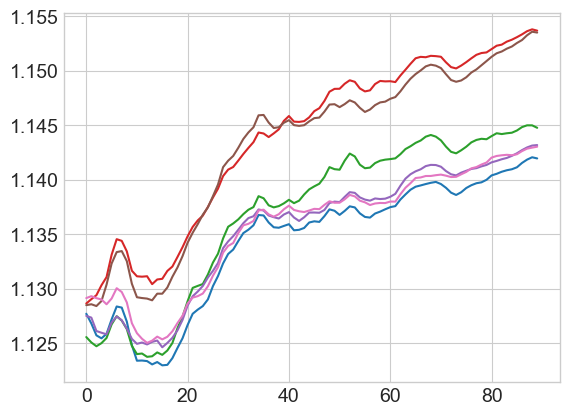

In [244]:
for mo in interactions.keys():
    homog = (inter_user_div[mo]**2 + intra_user_div[mo]**2)**(-0.5)
    values = gaussian_filter1d(homog.mean(axis=0), sigma=0.1)
    plt.plot(values[10:], color=colors[mo])
plt.show()

### Similar Users Homogenization (Chamfer distance)

In [245]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [246]:
chamfer = dict()
ideal_chamfer = dict()
for mo in interactions.keys():
    chamfer[mo] = []
    ideal_chamfer[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            chamfer_iter = 0
            ideal_chamfer_iter = 0
            #print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                chamfer_iter += (d.min(axis=1).mean() + d.min(axis=0).mean()) / (2*len(nearest_users))

                ideal_d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                ideal_chamfer_iter += (ideal_d.min(axis=1).mean() + ideal_d.min(axis=0).mean()) / (2*len(nearest_users))
            re.append(chamfer_iter)
            re2.append(ideal_chamfer_iter)
        chamfer[mo].append(re)
        ideal_chamfer[mo].append(re2)
    chamfer[mo] = np.array(chamfer[mo])
    ideal_chamfer[mo] = np.array(ideal_chamfer[mo])

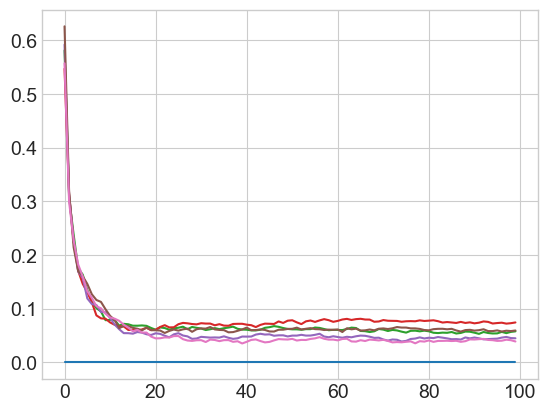

In [247]:
#plt.figure(figsize=(15,6))
for mo in interactions.keys():
    #plt.subplot(1, 2, 1)
    #values = gaussian_filter1d((chamfer[mo]**(-1)).mean(axis=0), sigma=0.1)
    #plt.plot(values[2:], color=colors[mo])
    #values = gaussian_filter1d((ideal_chamfer[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[2:], color=colors[mo][4:])
    #plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_chamfer[mo] - chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[0:], color=colors[mo])
plt.show()

## Distribución de Items

### Gini

In [248]:
gini = dict()
for mo in interactions.keys():
    gini[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        for j in range(interactions[mo][i].shape[1]):
            num_items = (j+1)*10
            user_iter_interactions = interactions[mo][i][:,:(j+1)]
            #print(interactions[mo][i].shape)
            numerator = 0.0
            denominator = 0.0
            gini_iter = 0
            for k in range(num_items):
                user_interactions_for_item = (user_iter_interactions == k).any(axis=1).sum()
                item_rank = np.argsort(np.argsort(np.bincount(user_iter_interactions.flatten(), minlength=num_items))[::-1])[k] + 1
                numerator += ((2*item_rank) - num_items - 1) * user_interactions_for_item
                denominator += user_interactions_for_item
            gini_iter = - numerator / (num_items * denominator)
            re.append(gini_iter)
        gini[mo].append(re)
    gini[mo] = np.array(gini[mo])

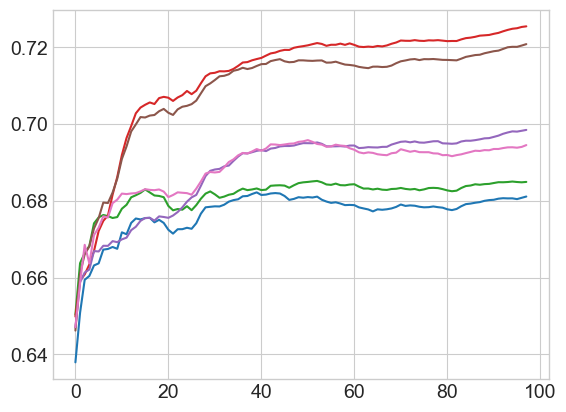

In [249]:
for mo in interactions.keys():
    values = gaussian_filter1d(gini[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[2:], color=colors[mo])
plt.show()

### Cobertura

In [250]:
cover = dict()
for mo in interactions.keys():
    cover[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        for j in range(interactions[mo][i].shape[1]):
            num_items = (j+1)*10
            user_iter_interactions = interactions[mo][i][:,:(j+1)]
            cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
            re.append(cover_iter)
        cover[mo].append(re)
    cover[mo] = np.array(cover[mo])

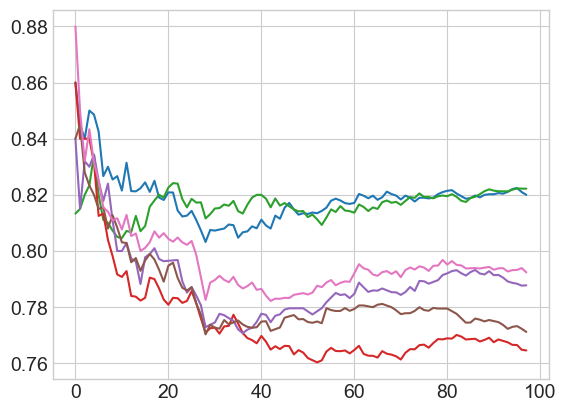

In [251]:
for mo in interactions.keys():
    values = gaussian_filter1d(cover[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[2:], color=colors[mo])
plt.show()

In [252]:
util_mean = dict()
for mo in utilities.keys():
    util_mean[mo] = []
    for i in range(utilities[mo].shape[0]):
        re = []
        for j in range(utilities[mo][i].shape[1]):
            util_mean_iter = utilities[mo][i][:,:(j+1)].mean()
            re.append(util_mean_iter)
        util_mean[mo].append(re)
    util_mean[mo] = np.array(util_mean[mo])

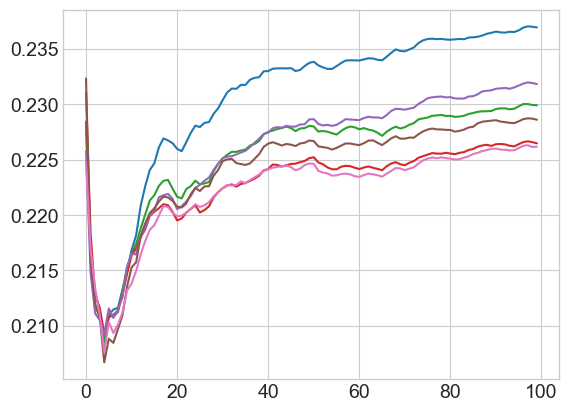

In [253]:
for mo in interactions.keys():
    values = gaussian_filter1d(util_mean[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[0:], color=colors[mo])
    
    #std = util_mean[mo].std(axis=0)
    #mtus = np.arange(len(std))
    #low = values - 1 * std
    #high = values + 1 * std
    #low = gaussian_filter1d(low, sigma=0.1)
    #high = gaussian_filter1d(high, sigma=0.1)
    #plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

## Distribución de Feeds

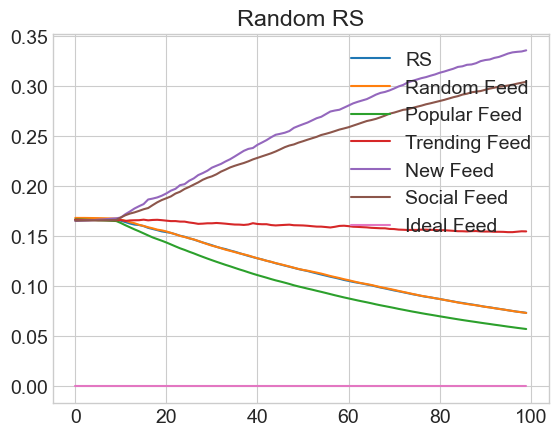

In [27]:
feed_labels = [
    "RS",
    "Random Feed",
    "Popular Feed",
    "Trending Feed",
    "New Feed",
    "Social Feed",
    "Ideal Feed"
    ]
feed_colors = np.array([
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
])
for i in range(7):
    plt.plot(traits["random"][:,:,:,i].mean(axis=0).mean(axis=0), label=feed_labels[i])
    plt.title("Random RS")
    plt.legend()

In [265]:
l = np.array([5,2,7,4,1])
np.argsort(l)[-2]

0

In [58]:
s = {feed_colors[i] : feed_labels[i] for i in range(feed_colors.shape[0])}

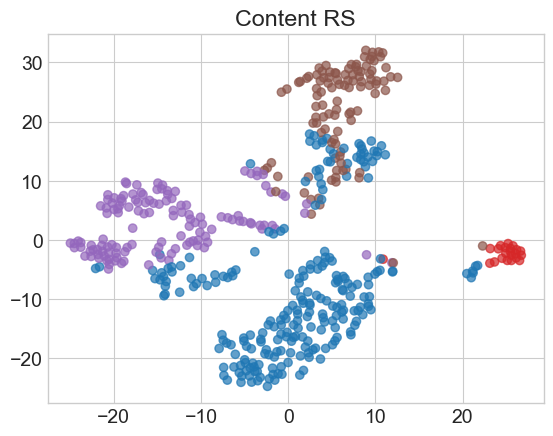

In [119]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
raw_data = traits["content_reduced"][:,:,99,:].reshape((-1,7))
X_scaled = scaler.fit_transform(raw_data)

# 3. Apply t-SNE (Reducing to 2D)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=feed_colors[np.argsort(raw_data, axis=1)[:,-1]], cmap='viridis', alpha=0.7)
plt.title("Content RS")
plt.show()